In [1]:
import os
import numpy as np
from Python_Scripts.ST import *
import Python_Scripts.QuantBacktester as qd
import Python_Scripts.mass as mk
import Python_Scripts.garch as garch
from scipy import stats, signal
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
wSize = [45, 60, 90, 100]

excelReaderfObj = qd.ExcelInputReader()
universeFilePath = r'D:\Linear Model\data\Universe\TradingDays.xlsx'  #'G:/.shortcut-targets-by-id/0B7f_UMMZHM_JNXljMVVXY2VPcHM/Investment Research_N/Manu/Universe/TradingDays.xlsx'
allTradingDatesDf = excelReaderfObj.getTradingDatesDataFrame(excelFile=universeFilePath, sheetName='Sheet1')
allTradingDatesDf.reset_index(drop=True, inplace=True)
ricDict = {
    '.NSEI': r'D:\Linear Model\data\Universe\INDTradingDays.xlsx'}  #'G:/.shortcut-targets-by-id/0B7f_UMMZHM_JNXljMVVXY2VPcHM/Investment Research_N/Manu/Universe/INDTradingDays.xlsx'}
priceDf = qd.UtilsQB().setDatFrame(allTradingDatesDf, ricDict)
#mainFolderPath = r'D:\Linear Model\data\RSI\Final'
mainFolderPath = os.path.join("data", "RSI", "Final", "NSEI")
freq = 'W'
existingFilePath = os.path.join(mainFolderPath, f"{freq}_allRebal.xlsx")
currentDf = excelReaderfObj.getDataFrame(existingFilePath, rowsToSkip=0, columnsToSkip=0)
currentDf.set_index('Date', inplace=True)
niftyCloseDf = priceDf[3][['.NSEI']]

In [3]:
def getDp(niftyCloseDf, dte, w):
    sim = mk.Match(niftyCloseDf.loc[niftyCloseDf.first_valid_index():], dte, windowSize=w, threshold=0.9)
    dp = sim.getDates()
    return dp


def getSimulateDf(niftyCloseDf, dte, w, dp, rep=35):
    qRoi = niftyCloseDf.iloc[niftyCloseDf.index.get_loc(dp) - 13:][:w + 14]
    frCoff = tsa.FractionEstimate(np.log(qRoi), numLag=14, interval=0.1, confidence=0.95, tolerance=1e-4).getBest()
    if frCoff != 1:
        qFD = tsa.FractionalDifferencing(numLag=14, fraction=frCoff, tolerance=1e-4)
        qFR = qFD.getDifferencedSeries(np.log(qRoi))

        # print(qFR)
        qFRIC = arma.ModelSelection(qFR.values.flatten(), 5, 5).getICseries()
        qFRIC.sort_values("AIC", inplace=True)
        # print(qFRIC)
        p, q = qFRIC.loc[qFRIC.index[0]]['p'], qFRIC.loc[qFRIC.index[0]]['q']

        # print(p,q)
        mod = arma.Model(qFR, p=int(p), q=int(q))
        mod.getParams()

        oRoi = niftyCloseDf.loc[:dte][-15:]
        oFD = tsa.FractionalDifferencing(numLag=14, fraction=frCoff, tolerance=1e-4)
        oFR = oFD.getDifferencedSeries(np.log(oRoi))

        sims = arma.SimulateFD(mod, init_Val=oFR.iloc[0].values.flatten(), repetition=rep).getFDValues()
        simPrice = []
        for i in range(rep):
            simPrice.append(tsa.BackOperation(niftyCloseDf.loc[:dte][-14:].values.flatten(), sims.iloc[:, i],
                                              fraction=frCoff).getPrediction().values.flatten())
        simulatedPriceDf = pd.DataFrame(simPrice).T
        ci = niftyCloseDf.index.get_loc(dte)
        simulatedPriceDf.index = niftyCloseDf.iloc[ci - 13:ci + 23].index

        return p, q, qRoi, qFR, qFRIC, oRoi, oFR, simulatedPriceDf
    else:
        return -999


def getBeta(niftyCloseDf, dte, w, dp, rep=35):
    qRoi = niftyCloseDf.iloc[niftyCloseDf.index.get_loc(dp) - 13:][:w + 14]
    frCoff = tsa.FractionEstimate(np.log(qRoi), numLag=14, interval=0.1, confidence=0.95, tolerance=1e-4).getBest()
    if frCoff != 1:
        qFD = tsa.FractionalDifferencing(numLag=14, fraction=frCoff, tolerance=1e-4)
        qFR = qFD.getDifferencedSeries(np.log(qRoi))

        # print(qFR)
        # qFRIC = arma.ModelSelection(qFR.values.flatten(),5,5).getICseries()
        # qFRIC.sort_values("AIC", inplace= True)
        # # print(qFRIC)
        # p, q= qFRIC.loc[qFRIC.index[0]]['p'], qFRIC.loc[qFRIC.index[0]]['q']

        # print(p,q)
        mod = arma.Model(qFR, p=int(8), q=int(0))
        params = mod.getParams()

        return params.loc['ar.L1']['Coefficient']
    else:
        return -999


def remove_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return series[(series >= lower_bound) & (series <= upper_bound)]


def getComp(niftyCloseDf, predictionDf):
    mCol = niftyCloseDf.columns[0]
    tmpDf = niftyCloseDf.loc[predictionDf.index][[mCol]]
    tmpDf.loc[predictionDf.index, 'Prediction'] = predictionDf.values

    mean_mCol = tmpDf[mCol].pct_change(1).mean()
    std_mCol = tmpDf[mCol].pct_change(1).std()

    mean_Prediction = tmpDf['Prediction'].pct_change(1).mean()
    std_Prediction = tmpDf['Prediction'].pct_change(1).std()

    # Correlation
    correlation = tmpDf[mCol].corr(tmpDf['Prediction'])

    ret_mCol = tmpDf.loc[tmpDf.index[-1]][mCol] / tmpDf.loc[tmpDf.index[0]][mCol] - 1
    ret_Prediction = tmpDf.loc[tmpDf.index[-1]]['Prediction'] / tmpDf.loc[tmpDf.index[0]]['Prediction'] - 1

    return mean_mCol, mean_Prediction, ret_mCol, ret_Prediction, std_mCol, std_Prediction, correlation, tmpDf


def getCompBeta(niftyCloseDf, dte):
    mCol = niftyCloseDf.columns[0]
    tmpDf = niftyCloseDf[[mCol]]
    currentRet = tmpDf.loc[dte][mCol] / tmpDf.iloc[tmpDf.index.get_loc(dte) - 13][mCol] - 1
    fwdRet = tmpDf.iloc[tmpDf.index.get_loc(dte) + 13][mCol] / tmpDf.loc[dte][mCol] - 1

    return currentRet, fwdRet

0.4


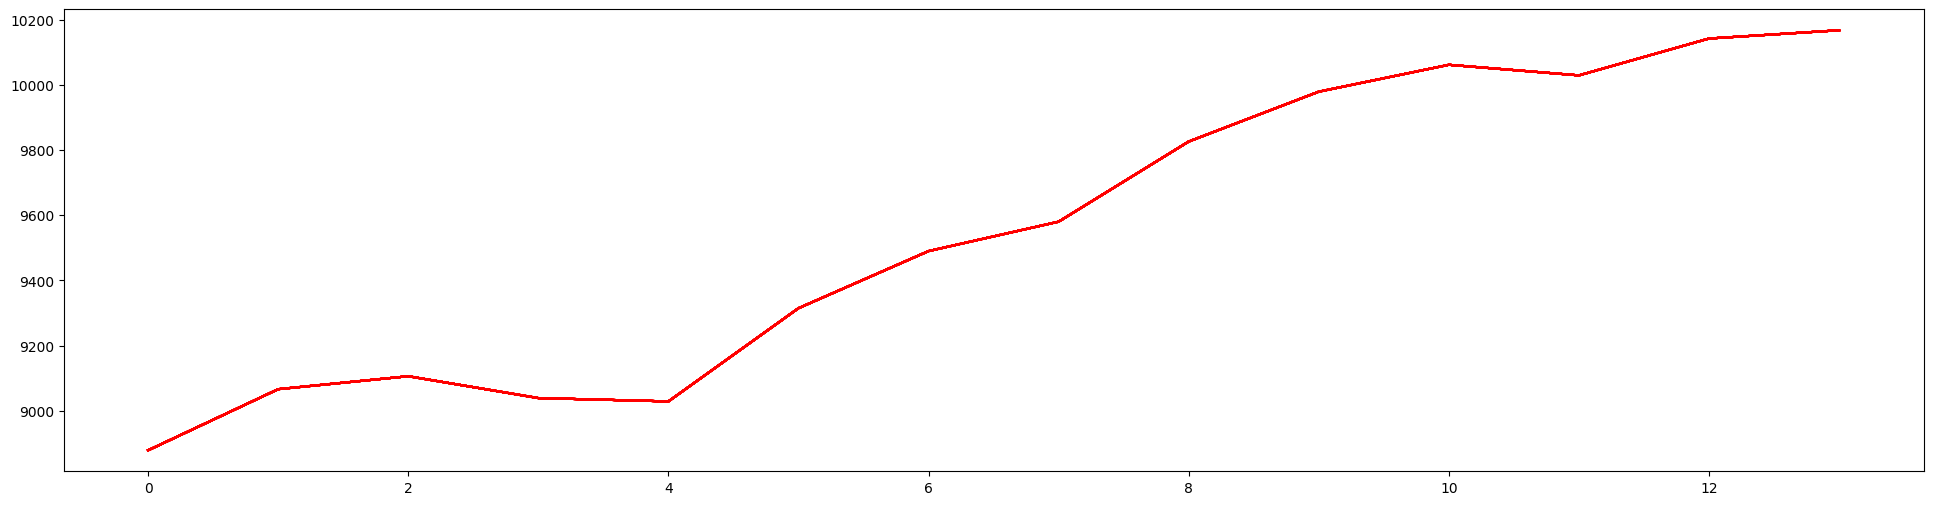

In [4]:
sim = mk.Match(priceDf[3][['.NSEI']].loc[priceDf[3]['.NSEI'].first_valid_index():], '2020-06-08', windowSize=wSize[0],
               threshold=0.8)

ans = sim.getMatchIndex()
reg = sim.getRegime()

dp = sim.getDates()
best_date = dp.index[0]          # or dp.sort_values('Distance').index[0]

import Python_Scripts.tsa as tsa
st = niftyCloseDf.index.get_loc(best_date) - 13
en = st + 90 + 14
qRoi = niftyCloseDf.iloc[st:en]

frCoff = tsa.FractionEstimate(qRoi, numLag=14, interval=0.1, confidence=0.95, tolerance=1e-4).getBest()
print(frCoff)

qFD = tsa.FractionalDifferencing(numLag=14, fraction=frCoff, tolerance=1e-4)
qFR = qFD.getDifferencedSeries(qRoi)

import Python_Scripts.arma as arma

qFR12IC = arma.ModelSelection(qFR.values.flatten(), 14, 14).getICseries()
qFR12IC.sort_values("AIC").head()
mod12 = arma.Model(qFR, p=1, q=0)
params = mod12.getParams()
rep = 35

oRoi = priceDf[3][['.NSEI']].loc[:'2020-06-08'][-15:]
oFD = tsa.FractionalDifferencing(numLag=14, fraction=frCoff, tolerance=1e-4)
oFR = oFD.getDifferencedSeries((oRoi))

sims12 = arma.SimulateFD(mod12, init_Val=oFR.iloc[0].values.flatten(), repetition=rep).getFDValues()
fig, ax = plt.subplots(figsize=(24, 6))
simPrice = []
for i in range(rep):
    simPrice.append(
        tsa.BackOperation(priceDf[3][['.NSEI']].loc[:'2020-06-08'][-14:].values.flatten(), sims12.iloc[:, i],
                          fraction=frCoff).getPrediction().values.flatten())
pd.DataFrame(simPrice).T.plot(ax=ax, color='r')
ax.get_legend().remove()

In [5]:
simPrice

[array([ 8879.1 ,  9066.55,  9106.25,  9039.25,  9029.05,  9314.95,
         9490.1 ,  9580.3 ,  9826.15,  9979.1 , 10061.55, 10029.1 ,
        10142.15, 10167.45,      inf,      inf,      inf,      inf,
             inf,      inf,      inf,      inf,      inf,      inf,
             inf,      inf,      inf,      inf,      inf,      inf,
             inf,      inf,      inf,      inf,      inf,      inf]),
 array([ 8879.1 ,  9066.55,  9106.25,  9039.25,  9029.05,  9314.95,
         9490.1 ,  9580.3 ,  9826.15,  9979.1 , 10061.55, 10029.1 ,
        10142.15, 10167.45,      inf,      inf,      inf,      inf,
             inf,      inf,      inf,      inf,      inf,      inf,
             inf,      inf,      inf,      inf,      inf,      inf,
             inf,      inf,      inf,      inf,      inf,      inf]),
 array([ 8879.1 ,  9066.55,  9106.25,  9039.25,  9029.05,  9314.95,
         9490.1 ,  9580.3 ,  9826.15,  9979.1 , 10061.55, 10029.1 ,
        10142.15, 10167.45,      inf,      i

In [6]:
ans

(array([6118, 4219, 4220, ..., 3905, 4887, 4888], shape=(6075,)),
 DatetimeIndex(['2020-06-08', '2012-09-25', '2012-09-26', '1999-08-30',
                '2018-07-19', '1997-08-08', '2020-06-05', '2012-09-24',
                '2014-05-21', '1999-08-27',
                ...
                '2011-06-24', '2003-03-13', '2015-05-06', '2003-03-17',
                '2015-06-15', '1996-09-23', '2011-06-22', '2011-06-23',
                '2015-06-11', '2015-06-12'],
               dtype='datetime64[ns]', name='Date', length=6075, freq=None))

In [7]:
reg

,idx,start,end,dp
0,4219,2012-09-25,2012-12-03,3.093600
1,4220,2012-09-26,2012-12-04,3.338243
2,951,1999-08-30,1999-11-02,3.434133
3,5658,2018-07-19,2018-09-26,3.501771
4,439,1997-08-08,1997-10-20,3.525386
...,...,...,...,...
112,1946,2003-08-19,2003-10-22,4.420908
113,1068,2000-02-15,2000-04-24,4.421437
114,4192,2012-08-16,2012-10-22,4.421561
115,6006,2019-12-23,2020-02-25,4.422779


In [8]:
dp

,STDEV,Q,Distance,DDiff
Date,,,,
2012-09-25,153.801725,6185.108424,3.093600,2813 days
2012-09-26,156.937055,6187.724759,3.338243,2812 days
1999-08-30,56.526275,2210.367512,3.434133,7588 days
2018-07-19,143.320167,5570.682902,3.501771,690 days
1997-08-08,49.684423,1927.051452,3.525386,8340 days
...,...,...,...,...
2003-08-19,50.884802,1792.558914,4.420908,6138 days
2000-02-15,97.268192,3426.315473,4.421437,7419 days
2012-08-16,93.197782,3282.882596,4.421561,2853 days


In [9]:
best_date

Timestamp('2012-09-25 00:00:00')

In [10]:
st

4206

In [11]:
en

4310

In [12]:
qRoi

,.NSEI
Date,
2012-09-06,5238.40
2012-09-07,5342.10
2012-09-08,5358.70
2012-09-10,5363.45
2012-09-11,5390.00
...,...
2013-01-30,6055.75
2013-01-31,6034.75
2013-02-01,5998.90


In [13]:
frCoff

np.float64(0.4)

In [14]:
qFR

,0
0,1370.585398
1,1353.904949
2,1409.279891
3,1401.346870
4,1399.070735
...,...
85,1446.055718
86,1423.622226
87,1395.962409
88,1401.204751


In [15]:
params

,Coefficient,Tstat,P-value,Std. Error
Name,,,,
const,1346.720236,66.917633,0.0,20.125043
x1,1.109947,2.752738,0.00591,0.403216
ar.L1,0.63786,6.90507,0.0,0.092376
sigma2,1261.351371,5.251477,0.0,240.189814


In [16]:
oFD

In [17]:
oFR

,0
0,2571.537524


In [18]:
excelReaderfObj = qd.ExcelInputReader()
priceFilePath = r'D:\Linear Model\data\Universe\INDTradingDays.xlsx'
closeDf = excelReaderfObj.getDataFrame(priceFilePath, sheetName='Close')
closeDf.set_index('Date', inplace=True)
closeDf = closeDf[['.NSEI']]

In [19]:
closeDf

,.NSEI
Date,
1990-12-31,NaN
1991-01-01,NaN
1991-01-02,NaN
1991-01-03,NaN
1991-01-04,NaN
...,...
2025-09-15,25069.20
2025-09-16,25239.10
2025-09-17,25330.25


In [20]:
universeFilePath = r'D:\Linear Model\data\Universe\TradingDays.xlsx'
allTradingDatesDf = excelReaderfObj.getTradingDatesDataFrame(excelFile=universeFilePath, sheetName='Sheet1',
                                                             startDate=closeDf.first_valid_index())
allTradingDatesDf.reset_index(drop=True, inplace=True)
monthEndDatesDf = allTradingDatesDf.loc[allTradingDatesDf.groupby('YearMonth').Date.idxmax()]
monthEndDatesDf.sort_values(by=['Date'], inplace=True)



In [21]:
monthEndDatesDf

,Date,Month,Year,YearMonth
19,1995-11-30,11,1995,199511
39,1995-12-29,12,1995,199512
61,1996-01-31,1,1996,19961
81,1996-02-29,2,1996,19962
100,1996-03-29,3,1996,19963
...,...,...,...,...
7356,2025-05-30,5,2025,20255
7377,2025-06-30,6,2025,20256
7400,2025-07-31,7,2025,20257
7419,2025-08-29,8,2025,20258


In [22]:
mergeObj = qd.Merger()
closeMergedDf = mergeObj.getMergedBymethodDf(allTradingDatesDf, closeDf)

In [23]:
closeMergedDf

,.NSEI
Date,
1995-11-03,1000.00
1995-11-06,988.92
1995-11-07,978.22
1995-11-08,964.01
1995-11-09,953.07
...,...
2025-09-15,25069.20
2025-09-16,25239.10
2025-09-17,25330.25


In [24]:
rebalDates = ['2021-10-29',
              '2021-11-30',
              '2021-12-31',
              '2022-01-31',
              '2022-02-28',
              '2022-03-31',
              '2022-04-29',
              '2022-05-31',
              '2022-06-30',
              '2022-07-29',
              '2022-08-30',
              '2022-09-30',
              ]
rebalDates = ['2024-10-18']

In [25]:
resultDf = pd.DataFrame(columns=['Ret_Avg', 'Std_Avg', 'Avg_Ret', 'Avg_Std'], index=rebalDates)
resultDf14 = pd.DataFrame(columns=['Ret_Avg', 'Std_Avg', 'Avg_Ret', 'Avg_Std'], index=rebalDates)
stDf = pd.DataFrame(index=rebalDates, columns=['12', '14'])

In [26]:
resultDf14

,Ret_Avg,Std_Avg,Avg_Ret,Avg_Std
2024-10-18,NaN,NaN,NaN,NaN


In [27]:

i = 0

rebalDate = rebalDates[i]

wSize = [45, 60, 90, 100]

sim = mk.Match(closeMergedDf, rebalDate, windowSize=wSize[0], threshold=0.85)
reg = sim.getRegime()

print(reg)
print(rebalDate)

indexLists = [1, 2,3,4]

    idx      start        end        dp
0  5555 2018-02-20 2018-04-27  3.207108
1  5556 2018-02-21 2018-04-30  3.590996
2  5554 2018-02-19 2018-04-26  3.599230
3  2310 2005-01-24 2005-03-30  3.825316
4  2309 2005-01-20 2005-03-29  3.846647
2024-10-18


1
2
3
4


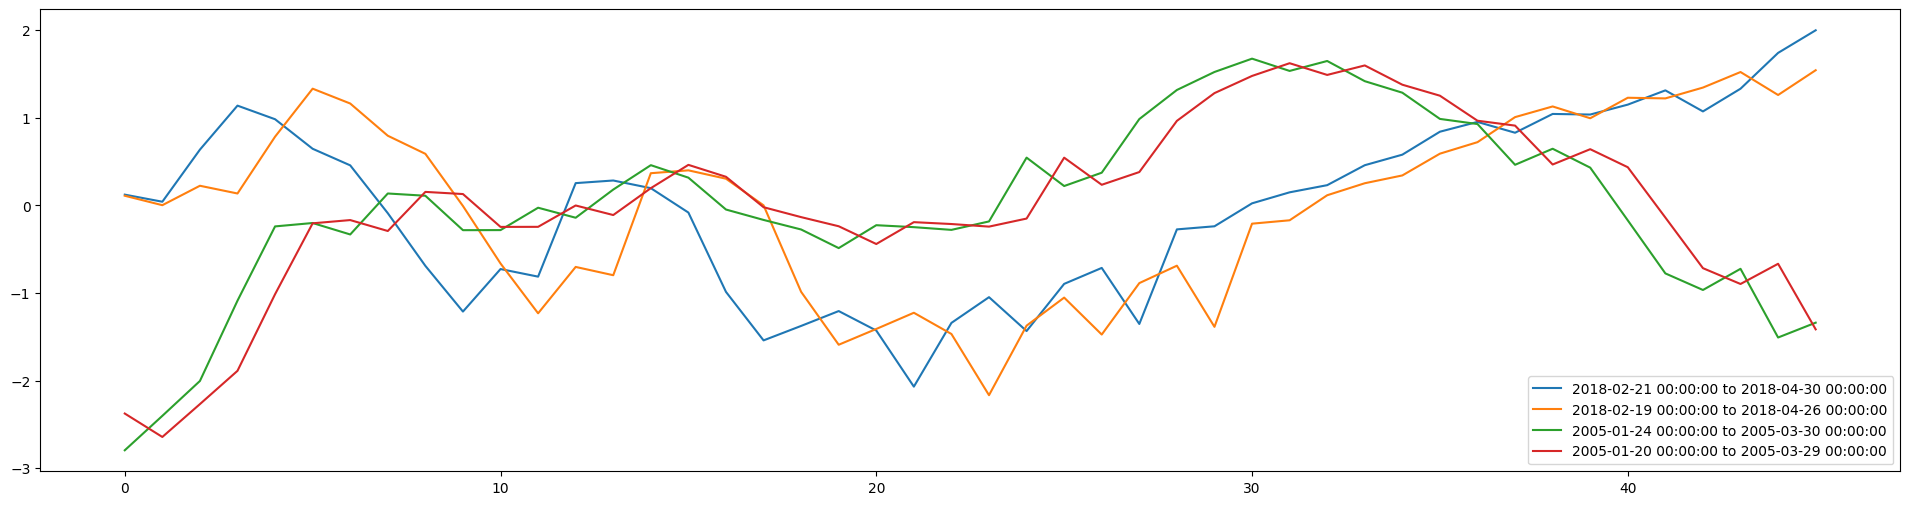

In [28]:
plt.figure(figsize=(24, 6))
ax = plt.gca()
# sim.plotMatch(ax)
for i in indexLists:
    ax.plot(stats.zscore(closeMergedDf.loc[reg.iloc[i].start: reg.iloc[i].end].values),
            label='{} to {}'.format(str(reg.iloc[i].start), str(reg.iloc[i].end)))

    print(i)
# ax.plot(stats.zscore(closeMergedDf.loc[reg.iloc[0].start: reg.iloc[0].end].values), color='k', lw=4, label='Query')
ax.legend()

In [29]:
qReg = tsa.Preprocess(closeMergedDf, start=reg.start.iloc[indexLists[1]], end=reg.end.iloc[indexLists[1]]).getProcessedData()
qRegRet = tsa.Returns(qReg).getLogReturns()

In [30]:

qRoi = tsa.Preprocess(closeMergedDf, start=reg.end.iloc[indexLists[1]] - datetime.timedelta(21),).getProcessedData()[:90+14]
print(qRoi)

               .NSEI
Date                
2018-04-05  10325.15
2018-04-06  10331.60
2018-04-09  10379.35
2018-04-10  10402.25
2018-04-11  10417.15
...              ...
2018-08-27  11691.95
2018-08-28  11738.50
2018-08-29  11691.90
2018-08-30  11676.80
2018-08-31  11680.50

[104 rows x 1 columns]


In [31]:
frCoff = tsa.FractionEstimate(np.log(qRoi), numLag=14, interval=0.1, confidence=0.95, tolerance=1e-4).getBest()
print(frCoff)

0.7


<Axes: >

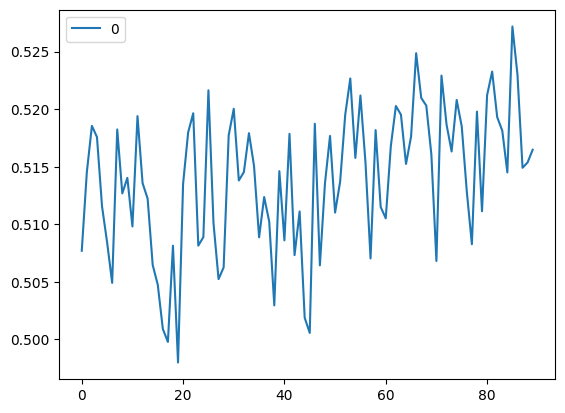

In [32]:
qFD = tsa.FractionalDifferencing(numLag=14, fraction= frCoff, tolerance=1e-4)
qFR = qFD.getDifferencedSeries(np.log(qRoi))
qFR.plot()

In [33]:
qFR12 = qFR[:45]
qFR14 = qFR[:90]

In [34]:
oRoi = closeMergedDf.loc[:rebalDate][-15:]
oFD = tsa.FractionalDifferencing(numLag=14, fraction= frCoff, tolerance=1e-4)
oFR = oFD.getDifferencedSeries(np.log(oRoi))

In [48]:
oFR

,0
0,0.558433


In [35]:
rep = 35

# ---- 2 month ---------------

qFR12IC = arma.ModelSelection(qFR12.values.flatten(), 5, 5).getICseries()

qFR12IC.sort_values("BIC").head()

,p,q,AIC,BIC
0,0,0,-331.291366,-327.678042
5,1,0,-332.371131,-326.951143
1,0,1,-331.863330,-326.443343
3,0,3,-334.151797,-325.118485
2,0,2,-331.068650,-323.842000


In [36]:
mod12 = arma.Model(qFR12, p = 0, q = 0)
# mod12 = arma.Model(qFR12, p = 1, q = 0)
mod12.getParams()

,Coefficient,Tstat,P-value,Std. Error
Name,,,,
const,0.511886,255.20002,0.0,0.002006
x1,-0.000026,-0.341382,0.732816,0.000078
sigma2,0.000034,3.770774,0.000163,0.000009


In [37]:
sims12 = arma.SimulateFD(mod12, init_Val=oFR.iloc[0].values.flatten(), repetition=rep).getFDValues()

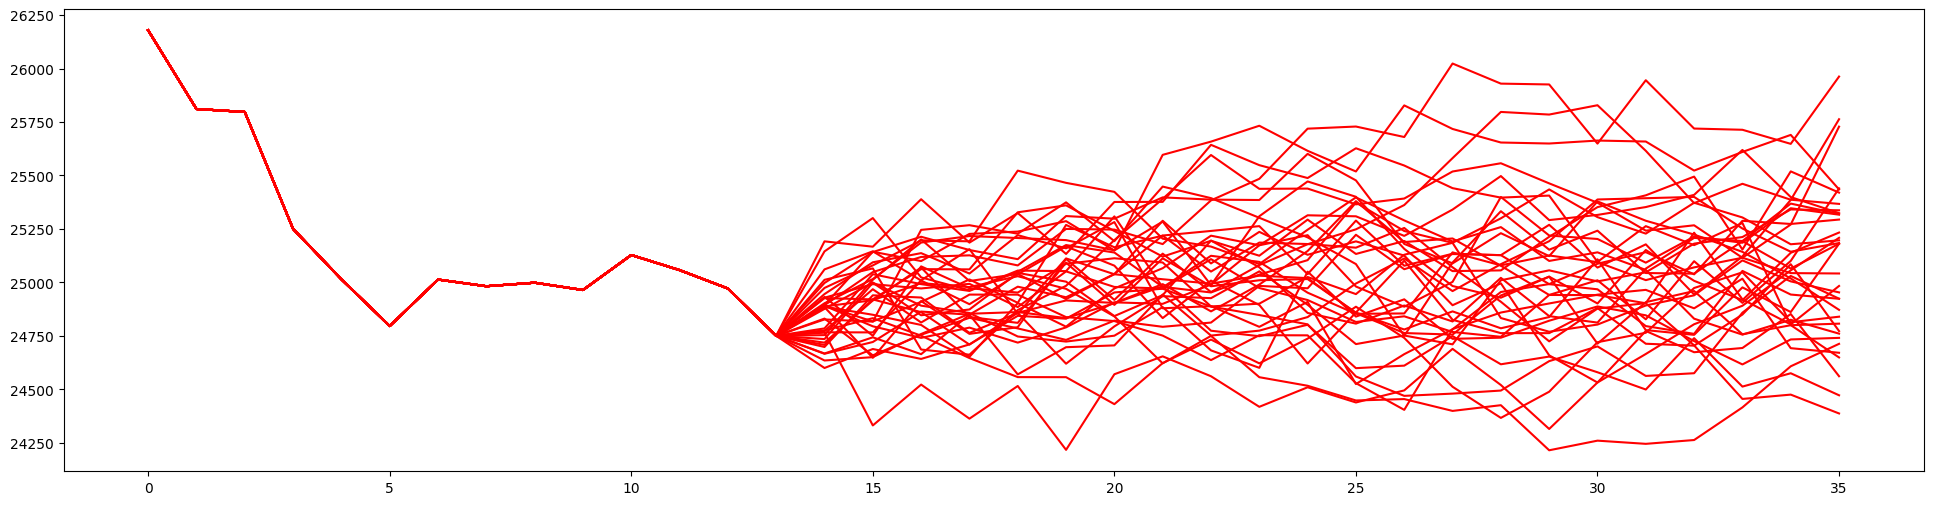

In [38]:
fig, ax = plt.subplots(figsize=(24, 6))
simPrice= []
for i in range(rep):
    simPrice.append(tsa.BackOperation(oRoi.values.flatten(), sims12.iloc[:, i], fraction= frCoff).getPrediction().values.flatten())
pd.DataFrame(simPrice).T.plot(ax=ax, color='r')
ax.get_legend().remove()

In [39]:
qFR14IC = arma.ModelSelection(qFR14.values.flatten(), 5, 5).getICseries()
qFR14IC.sort_values("BIC").head()

,p,q,AIC,BIC
5,1,0,-666.302088,-658.802659
6,1,1,-666.773688,-656.774449
1,0,1,-663.709696,-656.210267
10,2,0,-665.522008,-655.522769
2,0,2,-663.361360,-653.362121


In [40]:
mod14 = arma.Model(qFR14, p = 1, q = 0)
# mod14 = arma.Model(qFR14, p = 1, q = 0)
# mod14 = arma.Model(qFR14, p = 3, q = 1)
mod14.getParams()

,Coefficient,Tstat,P-value,Std. Error
Name,,,,
const,0.509313,329.763576,0.0,0.001544
x1,0.000101,3.244857,0.001175,0.000031
ar.L1,0.223238,2.022894,0.043084,0.110356
sigma2,0.00003,5.174342,0.0,0.000006


In [41]:
sims14 = arma.SimulateFD(mod14, init_Val=oFR.iloc[0].values.flatten(), repetition= rep).getFDValues()

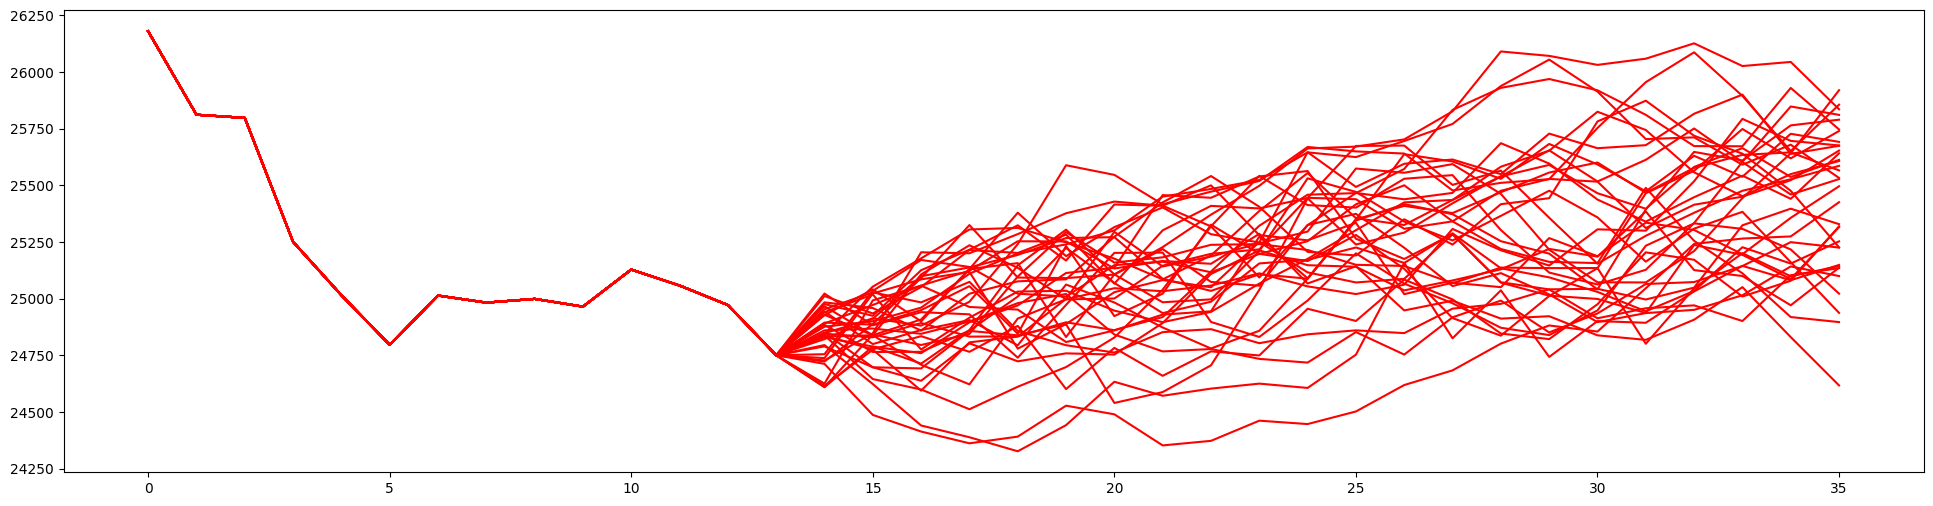

In [42]:
fig, ax = plt.subplots(figsize=(24, 6))
simPrice14  = []
for i in range(rep):
    simPrice14.append(tsa.BackOperation(oRoi.values.flatten(), sims14.iloc[:, i], fraction= frCoff).getPrediction().values.flatten())
pd.DataFrame(simPrice14).T.plot(ax=ax, color='r')
ax.get_legend().remove()

In [43]:
simulDf12 = pd.DataFrame(simPrice).T
simulDf14 = pd.DataFrame(simPrice14).T

In [44]:
resultDf.loc[rebalDate]['Ret_Avg'] = np.mean(simulDf12.apply(lambda x : (x[35] / x[13])-1))
resultDf.loc[rebalDate]['Std_Avg'] = np.mean(simulDf12.apply(lambda x : np.std(x.pct_change(1))))
resultDf.loc[rebalDate]['Avg_Ret'] = (simulDf12.mean(1)[35] / simulDf12.mean(1)[0]) - 1
resultDf.loc[rebalDate]['Avg_Std'] = simulDf12.mean(1).pct_change(1).std()
stDf.loc[rebalDate]['12'] = np.mean(simulDf12.pct_change(1).std())

In [45]:
resultDf

,Ret_Avg,Std_Avg,Avg_Ret,Avg_Std
2024-10-18,0.01352,0.007209,-0.041807,0.005489


In [46]:
stDf

,12,14
2024-10-18,0.007314,NaN


In [47]:
simulDf12

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,...,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000,26178.950000
1,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,...,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000,25810.850000
2,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,...,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000,25796.900000
3,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,...,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000,25250.100000
4,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,...,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000,25014.600000
5,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,...,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000,24795.750000
6,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,...,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000,25013.150000
7,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,...,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000,24981.950000
8,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,...,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000,24998.450000
9,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,...,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000,24964.250000
